In [11]:
!pip install --upgrade summa
!pip install --upgrade nltk #3.9.1

In [12]:
!pip install beautifulsoup4

In [20]:
from importlib.metadata import version
import nltk
import torch
import summa
import pandas as pd
import os
import re
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
from bs4 import BeautifulSoup
import torch
from collections import Counter
import numpy as np
import urllib.request
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module='bs4')
nltk.download('stopwords')
print('=3')
print(nltk.__version__)
print(torch.__version__)
print(pd.__version__)
print(version('summa'))

=3
3.9.4
2.7.1+cu118
2.3.0
1.2.0


[nltk_data] Downloading package stopwords to /home/jovyan/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


### **Step 1. 데이터 수집하기**

In [21]:
import urllib.request
urllib.request.urlretrieve("https://raw.githubusercontent.com/sunnysai12345/News_Summary/master/news_summary_more.csv", filename="news_summary_more.csv")
data = pd.read_csv('news_summary_more.csv', encoding='iso-8859-1')

In [22]:
data.sample(10)

,headlines,text
38862,"Three tourists, including Maha cop, drown off ...","Three tourists from Maharashtra, including a p..."
12403,"Cong seeks to meet Parrikar, cites 'zero publi...",Goa Congress MLA Aleixo Reginaldo Lourenco sai...
24722,70-year-old shopkeeper rapes 4-year-old girl i...,A 4-year-old girl was allegedly raped by the 7...
6215,Afghanistan's Rashid Khan pulls off 'Helicopte...,"Afghanistan spinner Rashid Khan pulled off a ""..."
70627,9 Pak players for World XI series have never p...,Nine players in Pakistan's 15-man squad for th...
92234,Mumbai remain on top of IPL points table with ...,Mumbai Indians defeated Delhi Daredevils by 14...
86145,"George Clooney, wife Amal become parents to twins",Actor George Clooney and his wife human rights...
53954,Why can't breastfeeding be made compulsory?: M...,The Madras High Court on Wednesday asked the C...
8282,UP CM gets legal notice for calling Lord Hanum...,Rajasthan Sarv Brahmin Mahasabha President Sur...
47425,"Akshaye, Richa to star in film on misuse of ra...",Akshaye Khanna and Richa Chadha will star in t...


### **Step 2.데이터 전처리하기 (추상적 요약)**

- 중복 샘플과 null 값이 존재하는 샘플제거

In [23]:
print('Text 열에서 중복을 배제한 유일한 샘플의 수 :', data['text'].nunique())
print('Headlines 열에서 중복을 배제한 유일한 샘플의 수 :', data['headlines'].nunique())

# inplace=True 를 설정하면 DataFrame 타입 값을 return 하지 않고 data 내부를 직접적으로 바꿉니다
data.drop_duplicates(subset = ['text'], inplace=True)
print('중복을 제거한 전체 샘플수 :', (len(data)))

Text 열에서 중복을 배제한 유일한 샘플의 수 : 98360
Headlines 열에서 중복을 배제한 유일한 샘플의 수 : 98280
중복을 제거한 전체 샘플수 : 98360


In [24]:
print(data.isnull().sum())

headlines    0
text         0
dtype: int64


- 불용어 제거를 위한 **텍스트 정규화(text normalization)**

In [25]:
contractions = {"ain't": "is not", "aren't": "are not","can't": "cannot", "'cause": "because", "could've": "could have", "couldn't": "could not",
                           "didn't": "did not",  "doesn't": "does not", "don't": "do not", "hadn't": "had not", "hasn't": "has not", "haven't": "have not",
                           "he'd": "he would","he'll": "he will", "he's": "he is", "how'd": "how did", "how'd'y": "how do you", "how'll": "how will", "how's": "how is",
                           "I'd": "I would", "I'd've": "I would have", "I'll": "I will", "I'll've": "I will have","I'm": "I am", "I've": "I have", "i'd": "i would",
                           "i'd've": "i would have", "i'll": "i will",  "i'll've": "i will have","i'm": "i am", "i've": "i have", "isn't": "is not", "it'd": "it would",
                           "it'd've": "it would have", "it'll": "it will", "it'll've": "it will have","it's": "it is", "let's": "let us", "ma'am": "madam",
                           "mayn't": "may not", "might've": "might have","mightn't": "might not","mightn't've": "might not have", "must've": "must have",
                           "mustn't": "must not", "mustn't've": "must not have", "needn't": "need not", "needn't've": "need not have","o'clock": "of the clock",
                           "oughtn't": "ought not", "oughtn't've": "ought not have", "shan't": "shall not", "sha'n't": "shall not", "shan't've": "shall not have",
                           "she'd": "she would", "she'd've": "she would have", "she'll": "she will", "she'll've": "she will have", "she's": "she is",
                           "should've": "should have", "shouldn't": "should not", "shouldn't've": "should not have", "so've": "so have","so's": "so as",
                           "this's": "this is","that'd": "that would", "that'd've": "that would have", "that's": "that is", "there'd": "there would",
                           "there'd've": "there would have", "there's": "there is", "here's": "here is","they'd": "they would", "they'd've": "they would have",
                           "they'll": "they will", "they'll've": "they will have", "they're": "they are", "they've": "they have", "to've": "to have",
                           "wasn't": "was not", "we'd": "we would", "we'd've": "we would have", "we'll": "we will", "we'll've": "we will have", "we're": "we are",
                           "we've": "we have", "weren't": "were not", "what'll": "what will", "what'll've": "what will have", "what're": "what are",
                           "what's": "what is", "what've": "what have", "when's": "when is", "when've": "when have", "where'd": "where did", "where's": "where is",
                           "where've": "where have", "who'll": "who will", "who'll've": "who will have", "who's": "who is", "who've": "who have",
                           "why's": "why is", "why've": "why have", "will've": "will have", "won't": "will not", "won't've": "will not have",
                           "would've": "would have", "wouldn't": "would not", "wouldn't've": "would not have", "y'all": "you all",
                           "y'all'd": "you all would","y'all'd've": "you all would have","y'all're": "you all are","y'all've": "you all have",
                           "you'd": "you would", "you'd've": "you would have", "you'll": "you will", "you'll've": "you will have",
                           "you're": "you are", "you've": "you have"}

print("정규화 사전의 수: ", len(contractions))

정규화 사전의 수:  120


In [26]:
print('불용어 개수 :', len(stopwords.words('english') ))
print(stopwords.words('english'))

불용어 개수 : 198
['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "

#### **전처리**

In [68]:
import re
from nltk.corpus import stopwords

# 🔥 1. 미리 정의 (중요)
STOPWORDS = set(stopwords.words('english'))

RE_HTML = re.compile(r'<.*?>')
RE_PAREN = re.compile(r'\([^)]*\)')
RE_NON_ALPHA = re.compile(r'[^a-zA-Z]')
RE_S = re.compile(r"'s\b")
RE_M = re.compile(r'm{2,}')

def preprocess_sentence(sentence, remove_stopwords=True):
    sentence = sentence.lower()
    
    # 🔥 빠른 HTML 제거
    sentence = RE_HTML.sub('', sentence)
    
    # 🔥 정규식 처리
    sentence = RE_PAREN.sub('', sentence)
    sentence = sentence.replace('"', '')
    sentence = RE_S.sub('', sentence)
    sentence = RE_NON_ALPHA.sub(' ', sentence)
    sentence = RE_M.sub('mm', sentence)

    # 🔥 contractions (필요하면 유지)
    sentence = ' '.join(contractions.get(word, word) for word in sentence.split())

    # 🔥 stopwords 최적화
    if remove_stopwords:
        tokens = ' '.join(
            word for word in sentence.split()
            if word not in STOPWORDS and len(word) > 1
        )
    else:
        tokens = ' '.join(
            word for word in sentence.split()
            if len(word) > 1
        )

    return tokens

In [69]:
# 설치된 패키지를 사용하려면 커널을 다시 시작해야할 가능성 99%
!pip install lxml

In [70]:
# example 
temp_text = 'Everything I bought was great, infact I ordered twice and the third ordered was<br />for my mother and father.'
temp_summary = 'Great way to start (or finish) the day!!!'

print("text: ", preprocess_sentence(temp_text))
print("summary:", preprocess_sentence(temp_summary, False))  # 불용어를 제거하지 않습니다.

text:  everything bought great infact ordered twice third ordered wasfor mother father
summary: great way to start the day


### Text 데이터 전처리

In [71]:
# 전체 Text 데이터에 대한 전처리 : 10분 이상 시간이 걸릴 수 있습니다.
clean_text = []

for sentence in data['text']:
    clean_text.append(preprocess_sentence(sentence))

# 전처리 후 출력
print("Text 전처리 후 결과: ", clean_text[:5])

Text 전처리 후 결과:  ['saurav kant alumnus upgrad iiit pg program machine learning artificial intelligence sr systems engineer infosys almost years work experience program upgrad degree career support helped transition data scientist tech mahindra salary hike upgrad online power learning powered lakh careers', 'kunal shah credit card bill payment platform cred gave users chance win free food swiggy one year pranav kaushik delhi techie bagged reward spending cred coins users get one cred coin per rupee bill paid used avail rewards brands like ixigo bookmyshow ubereats cult fit', 'new zealand defeated india wickets fourth odi hamilton thursday win first match five match odi series india lost international match rohit sharma captaincy consecutive victories dating back march match witnessed india getting seventh lowest total odi cricket history', 'aegon life iterm insurance plan customers enjoy tax benefits premiums paid save taxes plan provides life cover age years also customers options insur

In [72]:
from copy import deepcopy

clean_text_origin = deepcopy(clean_text)

### Headlines 데이터 전처리

In [73]:
# 전체 headlines 데이터에 대한 전처리 : 5분 이상 시간이 걸릴 수 있습니다.
clean_headlines = []

for sentence in data['headlines']:
    clean_headlines.append(preprocess_sentence(sentence, remove_stopwords=False))

print("headlines 전처리 후 결과: ", clean_headlines[:5])

headlines 전처리 후 결과:  ['upgrad learner switches to career in ml al with salary hike', 'delhi techie wins free food from swiggy for one year on cred', 'new zealand end rohit sharma led india match winning streak', 'aegon life iterm insurance plan helps customers save tax', 'have known hirani for yrs what if metoo claims are not true sonam']


In [74]:
clean_headlines_origin = deepcopy(clean_headlines)

In [75]:
# data2= pd.DataFrame()
data['text'] = clean_text
data['haedlines'] = clean_headlines

# 빈 값을 Null 값으로 변환
data.replace('', np.nan, inplace=True)
print('=3')

=3


In [76]:
data.isnull().sum()

headlines         0
text              0
haedlines         0
decoder_input     0
decoder_target    0
dtype: int64

In [77]:
data.dropna(axis=0, inplace=True)
print('전체 샘플수 :', (len(data)))

전체 샘플수 : 98040


In [78]:
# clean_text

### **Step 3. 어텐션 메커니즘 사용하기 (추상적 요약)**

텍스트의 최소 길이 : 1
텍스트의 최대 길이 : 45
텍스트의 평균 길이 : 35.04145246838025
요약의 최소 길이 : 1
요약의 최대 길이 : 15
요약의 평균 길이 : 9.553080375356997


/tmp/ipykernel_136/377500445.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(


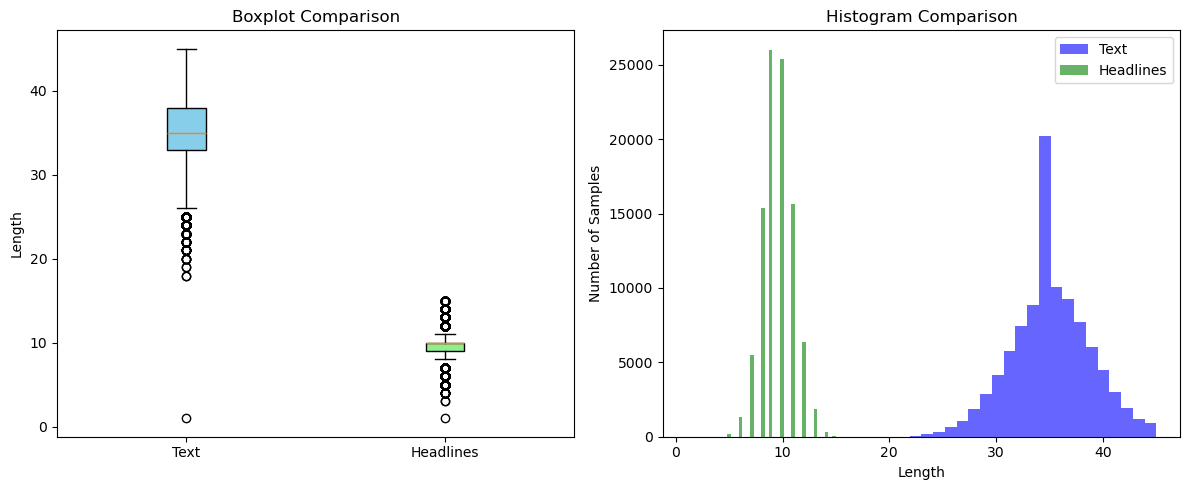

In [79]:
# 길이 분포 출력
import matplotlib.pyplot as plt

text_len = [len(s.split()) for s in data['text']]
summary_len = [len(s.split()) for s in data['headlines']]

print('텍스트의 최소 길이 : {}'.format(np.min(text_len)))
print('텍스트의 최대 길이 : {}'.format(np.max(text_len)))
print('텍스트의 평균 길이 : {}'.format(np.mean(text_len)))
print('요약의 최소 길이 : {}'.format(np.min(summary_len)))
print('요약의 최대 길이 : {}'.format(np.max(summary_len)))
print('요약의 평균 길이 : {}'.format(np.mean(summary_len)))



# 🔥 전체 figure 크기 키우기
plt.figure(figsize=(12, 5))

# ======================
# 📦 Boxplot (색상 적용)
# ======================
plt.subplot(1, 2, 1)

box = plt.boxplot(
    [text_len, summary_len],
    patch_artist=True,  # 색상 채우기 가능
    labels=['Text', 'Headlines']
)

# 색상 지정
colors = ['skyblue', 'lightgreen']
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)

plt.title('Boxplot Comparison')
plt.ylabel('Length')

# ======================
# 📊 Histogram (나란히)
# ======================
plt.subplot(1, 2, 2)

plt.hist(text_len, bins=40, alpha=0.6, label='Text', color='blue')
plt.hist(summary_len, bins=40, alpha=0.6, label='Headlines', color='green')

plt.title('Histogram Comparison')
plt.xlabel('Length')
plt.ylabel('Number of Samples')
plt.legend()

# 🔥 간격 자동 조정
plt.tight_layout()
plt.show()

- text의 평균 길이는 35정도이고, Headline의 평균 길이는 9.6 정도 된다
- text에서 maxlen 은 45 이상, headline에서는 15이상은 outlier로 봐도 될 것 같다

In [80]:
text_max_len = 45
headline_max_len = 15

In [81]:
def below_threshold_len(max_len, nested_list):
  cnt = 0
  for s in nested_list:
    if(len(s.split()) <= max_len):
        cnt = cnt + 1
  print('전체 샘플 중 길이가 %s 이하인 샘플의 비율: %s'%(max_len, (cnt / len(nested_list))))
print('=3')

=3


In [82]:
below_threshold_len(text_max_len, data['text'])
below_threshold_len(headline_max_len, data['headlines'])

전체 샘플 중 길이가 45 이하인 샘플의 비율: 1.0
전체 샘플 중 길이가 15 이하인 샘플의 비율: 1.0


- 1% 이하의 샘플들은 제거해보려고 한다

In [83]:
# 정해진 길이보다 길면 제외하는 방법으로 데이터를 정제
data = data[data['text'].apply(lambda x: len(x.split()) <= text_max_len)]
data = data[data['headlines'].apply(lambda x: len(x.split()) <= headline_max_len)]

print('전체 샘플수 :', (len(data)))

# <SOS> , <EOS> 추가
# 요약 데이터에는 시작 토큰과 종료 토큰을 추가한다.
data['decoder_input'] = data['headlines'].apply(lambda x : 'sostoken '+ x)
data['decoder_target'] = data['headlines'].apply(lambda x : x + ' eostoken')


encoder_input = np.array(data['text']) # 인코더의 입력
decoder_input = np.array(data['decoder_input']) # 디코더의 입력
decoder_target = np.array(data['decoder_target']) # 디코더의 레이블

# 훈련데이터와 테스트 데이터 분리
indices = np.arange(encoder_input.shape[0])
np.random.shuffle(indices)
encoder_input = encoder_input[indices]
decoder_input = decoder_input[indices]
decoder_target = decoder_target[indices]

# 섞인 데이터를 8:2 = train : test 로 분리
n_of_val = int(len(encoder_input)*0.2)
encoder_input_train = encoder_input[:-n_of_val]
decoder_input_train = decoder_input[:-n_of_val]
decoder_target_train = decoder_target[:-n_of_val]

encoder_input_test = encoder_input[-n_of_val:]
decoder_input_test = decoder_input[-n_of_val:]
decoder_target_test = decoder_target[-n_of_val:]

print('훈련 데이터의 개수 :', len(encoder_input_train))
print('훈련 레이블의 개수 :', len(decoder_input_train))
print('테스트 데이터의 개수 :', len(encoder_input_test))
print('테스트 레이블의 개수 :', len(decoder_input_test))


전체 샘플수 : 98040
훈련 데이터의 개수 : 78432
훈련 레이블의 개수 : 78432
테스트 데이터의 개수 : 19608
테스트 레이블의 개수 : 19608


### **정수 인코딩**

vocab 만들기

In [84]:
def src_tokenizer(text): # 토크나이저 정의
    text = text.lower()  # 소문자로 변환
    text = re.sub(r"[^a-zA-Z0-9]+", " ", text)  # 특수문자 제거
    return text.split()  # 공백 기준 토큰화

def build_vocab(texts):
    vocab = {"<PAD>": 0, "<UNK>": 1}  # 패딩과 UNK 토큰 추가
    word_counter = Counter()

    for text in texts:
        word_counter.update(src_tokenizer(text))  # 단어 빈도수 계산

    # 단어 집합 생성 (빈도가 높은 순서대로)
    for word, _ in word_counter.most_common():
        if word not in vocab:
            vocab[word] = len(vocab)

    return vocab

src_vocab = build_vocab(encoder_input_train) # 입력된 데이터로부터 단어 집합 생성
print('=3')

=3


In [85]:
threshold = 8

# 전처리된 데이터 사용
text_data = data['text'].tolist()
summary_data = data['haedlines'].tolist()
# 단어 빈도수 계산
word_counter = Counter()
for text in text_data:
    word_counter.update(text.split())

total_cnt = len(word_counter)  # 전체 단어 개수
total_freq = sum(word_counter.values())  # 전체 단어 등장 횟수
rare_cnt = sum(1 for count in word_counter.values() if count < threshold)  # 희귀 단어 개수
rare_freq = sum(count for count in word_counter.values() if count < threshold)  # 희귀 단어 등장 횟수

# 희귀 단어를 제외한 단어 사전 구축
vocab = {"<PAD>": 0, "<UNK>": 1}  # 패딩 및 미등록 단어 추가
word_index = {word: idx + 2 for idx, (word, count) in enumerate(word_counter.items()) if count >= threshold}

print('단어 집합(vocabulary)의 크기 :', total_cnt)
print('등장 빈도가 %s번 이하인 희귀 단어의 수: %s'%(threshold - 1, rare_cnt))
print('단어 집합에서 희귀 단어를 제외시킬 경우의 단어 집합의 크기 %s'%(total_cnt - rare_cnt))
print("단어 집합에서 희귀 단어의 비율:", (rare_cnt / total_cnt)*100)
print("전체 등장 빈도에서 희귀 단어 등장 빈도 비율:", (rare_freq / total_freq)*100)

단어 집합(vocabulary)의 크기 : 76029
등장 빈도가 7번 이하인 희귀 단어의 수: 53169
단어 집합에서 희귀 단어를 제외시킬 경우의 단어 집합의 크기 22860
단어 집합에서 희귀 단어의 비율: 69.93252574675452
전체 등장 빈도에서 희귀 단어 등장 빈도 비율: 3.3681330964318064


In [86]:
src_vocab_size = 78000

def build_limited_vocab(texts, vocab_size):
    vocab = {"<PAD>": 0, "<UNK>": 1}  # 패딩과 UNK 토큰 추가
    word_counter = Counter()

    for text in texts:
        word_counter.update(src_tokenizer(text))  # 단어 빈도수 계산

    # 빈도가 높은 상위 vocab_size - 2개 단어만 선택 (PAD, UNK 포함)
    for word, _ in word_counter.most_common(vocab_size - 2):
        vocab[word] = len(vocab)

    return vocab

src_vocab = build_limited_vocab(encoder_input_train, src_vocab_size)
print('=3')

=3


In [87]:
def text_to_sequence(texts, vocab):
    sequences = []
    for text in texts:
        sequence = [vocab.get(word, vocab["<UNK>"]) for word in src_tokenizer(text)]
        sequences.append(sequence)
    return sequences

# 텍스트 데이터 정수 시퀀스로 변환
encoder_input_train_seq = text_to_sequence(encoder_input_train, src_vocab)
encoder_input_test_seq = text_to_sequence(encoder_input_test, src_vocab)

# 잘 진행되었는지 샘플 출력
print(encoder_input_train_seq[:3])
print(encoder_input_test_seq[:3])

[[712, 281, 283, 70, 333, 817, 969, 813, 10958, 108, 29555, 520, 2662, 9254, 984, 7338, 281, 4999, 262, 4171, 161, 1011, 817, 969, 7774, 1140, 846, 31, 220, 283, 763, 2196, 8, 590, 135], [371, 21, 28, 1675, 449, 44525, 44526, 29556, 44527, 2926, 4, 14, 74, 1538, 261, 449, 2395, 7568, 21, 199, 2075, 148, 3777, 74, 8019, 2886, 11842, 5137, 3963, 3106, 537], [103, 59, 2, 4713, 4429, 389, 4091, 111, 3247, 111, 103, 3, 594, 674, 1801, 1961, 103, 3120, 103, 3, 1689, 5, 40, 6626, 3107, 613, 3, 98, 3, 3850, 103, 6128, 3, 2149, 3738]]
[[95, 6, 17, 126, 46, 282, 11289, 6, 437, 22, 4434, 4206, 22, 283, 146, 2, 4206, 6795, 1213, 9350, 348, 46, 653, 4206, 19585, 770, 4006, 8594, 22, 437, 2690, 4727, 6449, 979, 46, 2, 581, 20668, 4727], [131, 122, 534, 1595, 1294, 4348, 303, 23, 414, 1304, 14, 40612, 806, 59, 3572, 160, 16455, 6937, 1595, 131, 577, 806, 651, 806, 67, 131, 104, 1595, 129, 347, 12312, 1464, 4348, 8210, 957, 119], [2977, 16385, 1, 339, 2943, 410, 3519, 255, 3168, 946, 25571, 2351, 3550

### Decoder에서 동일하게 작업

In [88]:
def tar_tokenizer(text):
    text = text.lower()  # 소문자로 변환
    text = re.sub(r"[^a-zA-Z0-9]+", " ", text)  # 특수문자 제거
    return text.split()  # 공백 기준 토큰화

tar_vocab = build_vocab(decoder_input_train)
print('=3')

=3


In [89]:
threshold = 6

word_counter = Counter()
for text in decoder_input_train:
    word_counter.update(tar_tokenizer(text))  # 각 문장의 단어 빈도 계산

# 전체 단어 개수 및 등장 빈도 계산
total_cnt = len(word_counter)  # 전체 단어 개수
total_freq = sum(word_counter.values())  # 전체 단어 등장 횟수
rare_cnt = sum(1 for count in word_counter.values() if count < threshold)  # 희귀 단어 개수
rare_freq = sum(count for count in word_counter.values() if count < threshold)  # 희귀 단어 등장 횟수

print('단어 집합(vocabulary)의 크기 :', total_cnt)
print('등장 빈도가 %s번 이하인 희귀 단어의 수: %s'%(threshold - 1, rare_cnt))
print('단어 집합에서 희귀 단어를 제외시킬 경우의 단어 집합의 크기 %s'%(total_cnt - rare_cnt))
print("단어 집합에서 희귀 단어의 비율:", (rare_cnt / total_cnt)*100)
print("전체 등장 빈도에서 희귀 단어 등장 빈도 비율:", (rare_freq / total_freq)*100)

단어 집합(vocabulary)의 크기 : 31922
등장 빈도가 5번 이하인 희귀 단어의 수: 21093
단어 집합에서 희귀 단어를 제외시킬 경우의 단어 집합의 크기 10829
단어 집합에서 희귀 단어의 비율: 66.07668692437817
전체 등장 빈도에서 희귀 단어 등장 빈도 비율: 4.627043954092751


In [90]:
tar_vocab_size = 19000
tar_vocab = build_limited_vocab(decoder_input_train + decoder_target_train, tar_vocab_size)

# 텍스트 시퀀스를 정수 시퀀스로 변환
decoder_input_train_seq = text_to_sequence(decoder_input_train, tar_vocab)
decoder_target_train_seq = text_to_sequence(decoder_target_train, tar_vocab)
decoder_input_test_seq = text_to_sequence(decoder_input_test, tar_vocab)
decoder_target_test_seq = text_to_sequence(decoder_target_test, tar_vocab)

# 잘 변환되었는지 확인
print('input')
print('input ',decoder_input_train_seq[:5])
print('target')
print('decoder ',decoder_target_train_seq[:5])

input
input  [[2, 25, 21, 485, 4, 505, 16, 1402, 1912, 8, 4406, 815], [2, 163, 154, 352, 1, 1, 1, 1, 5, 2136, 66, 31, 98], [2, 2506, 2771, 6, 509, 4267, 3453, 1203, 10, 14, 95], [2, 4894, 1959, 13580, 29, 44, 6, 582, 10, 728, 412, 6, 187], [2, 1115, 269, 6361, 702, 574, 650, 45, 373, 1233]]
target
decoder  [[25, 21, 485, 4, 505, 16, 1402, 1912, 8, 4406, 815, 3], [163, 154, 352, 1, 1, 1, 1, 5, 2136, 66, 31, 98, 3], [2506, 2771, 6, 509, 4267, 3453, 1203, 10, 14, 95, 3], [4894, 1959, 13580, 29, 44, 6, 582, 10, 728, 412, 6, 187, 3], [1115, 269, 6361, 702, 574, 650, 45, 373, 1233, 3]]


In [91]:
drop_train = [index for index, sentence in enumerate(decoder_input_train) if len(sentence) == 1]
drop_test = [index for index, sentence in enumerate(decoder_input_test) if len(sentence) == 1]

print('삭제할 훈련 데이터의 개수 :', len(drop_train))
print('삭제할 테스트 데이터의 개수 :', len(drop_test))

encoder_input_train = [sentence for index, sentence in enumerate(encoder_input_train) if index not in drop_train]
decoder_input_train = [sentence for index, sentence in enumerate(decoder_input_train) if index not in drop_train]
decoder_target_train = [sentence for index, sentence in enumerate(decoder_target_train) if index not in drop_train]

encoder_input_test = [sentence for index, sentence in enumerate(encoder_input_test) if index not in drop_test]
decoder_input_test = [sentence for index, sentence in enumerate(decoder_input_test) if index not in drop_test]
decoder_target_test = [sentence for index, sentence in enumerate(decoder_target_test) if index not in drop_test]

print('훈련 데이터의 개수 :', len(encoder_input_train))
print('훈련 레이블의 개수 :', len(decoder_input_train))
print('테스트 데이터의 개수 :', len(encoder_input_test))
print('테스트 레이블의 개수 :', len(decoder_input_test))

삭제할 훈련 데이터의 개수 : 0
삭제할 테스트 데이터의 개수 : 0
훈련 데이터의 개수 : 78432
훈련 레이블의 개수 : 78432
테스트 데이터의 개수 : 19608
테스트 레이블의 개수 : 19608


In [92]:
from torch.nn.utils.rnn import pad_sequence

# 텐서 변환 함수 (리스트 → PyTorch 텐서)
def convert_to_tensor(sequences):
    return [torch.tensor(seq, dtype=torch.long) for seq in sequences]

# 패딩 적용 함수 (PyTorch `pad_sequence()` 활용)
def pad_sequences_pytorch(sequences, maxlen, padding_value=0):
    sequences = convert_to_tensor(sequences)  # 리스트를 텐서로 변환
    padded_seqs = pad_sequence(sequences, batch_first=True, padding_value=padding_value)  # 패딩 적용
    return padded_seqs[:, :maxlen]  # maxlen 길이로 자르기 (최대 길이 초과 방지)

# 패딩 적용
encoder_input_train = pad_sequences_pytorch(encoder_input_train_seq, maxlen=text_max_len)
encoder_input_test = pad_sequences_pytorch(encoder_input_test_seq, maxlen=text_max_len)
decoder_input_train = pad_sequences_pytorch(decoder_input_train_seq, maxlen=headline_max_len)
decoder_target_train = pad_sequences_pytorch(decoder_target_train_seq, maxlen=headline_max_len)
decoder_input_test = pad_sequences_pytorch(decoder_input_test_seq, maxlen=headline_max_len)
decoder_target_test = pad_sequences_pytorch(decoder_target_test_seq, maxlen=headline_max_len)

print('=3')
print(encoder_input_train)

=3
tensor([[ 712,  281,  283,  ...,    0,    0,    0],
        [ 371,   21,   28,  ...,    0,    0,    0],
        [ 103,   59,    2,  ...,    0,    0,    0],
        ...,
        [ 788,  368, 1017,  ...,    0,    0,    0],
        [  52,  555, 7822,  ...,    0,    0,    0],
        [1223,  259,   44,  ...,    0,    0,    0]])


## **Encoder**

In [93]:
import torch.nn as nn
import torch.nn.functional as F

# 인코더 설계 시작
embedding_dim = 128
hidden_size = 256
src_vocab_size = len(src_vocab)  # 단어 집합 크기

# 인코더
class Encoder(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size, num_layers=3, dropout=0.4):
        super(Encoder, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.lstm = nn.LSTM(
            embedding_dim, hidden_size, num_layers=num_layers,
            dropout=dropout, batch_first=True
        )

    def forward(self, x): # 인코더의 임베딩 층
        embedded = self.embedding(x)
        output, (hidden, cell) = self.lstm(embedded)  # LSTM 실행
        return output, hidden, cell

# 인코더 모델 생성
encoder = Encoder(src_vocab_size, embedding_dim, hidden_size, num_layers=3, dropout=0.4)

## **Deocder**

In [94]:
# 디코더 설계
class Decoder(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size, dropout=0.4, num_layers=3):
        super(Decoder, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.lstm = nn.LSTM(
            embedding_dim, hidden_size, num_layers=num_layers, dropout=dropout,
            batch_first=True
        )

    def forward(self, x, hidden, cell): # 디코더의 임베딩 층
        embedded = self.embedding(x)
        output, (hidden, cell) = self.lstm(embedded, (hidden, cell))  # 초기 상태를 인코더에서 전달받음
        return output, hidden, cell

# 디코더 모델 생성
decoder = Decoder(tar_vocab_size, embedding_dim, hidden_size, num_layers=3, dropout=0.4)

## **Seq2Seq**

In [95]:
# 디코더의 출력층
class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, vocab_size):
        super(Seq2Seq, self).__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.softmax_layer = nn.Linear(hidden_size, vocab_size)  # 출력층 정의

    def forward(self, encoder_input, decoder_input):
        # 인코더 실행
        encoder_output, hidden, cell = self.encoder(encoder_input)

        # 디코더 실행
        decoder_output, _, _ = self.decoder(decoder_input, hidden, cell)

        # 출력층 적용 (Softmax는 Loss 내부에서 적용되므로 생략 가능)
        output = self.softmax_layer(decoder_output)
        return output

# 모델 정의
model = Seq2Seq(encoder, decoder, tar_vocab_size)
print(model)

Seq2Seq(
  (encoder): Encoder(
    (embedding): Embedding(69509, 128)
    (lstm): LSTM(128, 256, num_layers=3, batch_first=True, dropout=0.4)
  )
  (decoder): Decoder(
    (embedding): Embedding(19000, 128)
    (lstm): LSTM(128, 256, num_layers=3, batch_first=True, dropout=0.4)
  )
  (softmax_layer): Linear(in_features=256, out_features=19000, bias=True)
)


## **Attention**

In [96]:
class Attention_dot(nn.Module):
    def __init__(self, hidden_size):
        super(Attention_dot, self).__init__()
        self.attn = nn.Linear(hidden_size, hidden_size)  # 어텐션 가중치
        self.v = nn.Linear(hidden_size, 1, bias=False)  # 어텐션 가중치 벡터

    def forward(self, decoder_output, encoder_outputs):
        attn_weights = torch.bmm(decoder_output, encoder_outputs.transpose(1, 2))
        attn_weights = F.softmax(attn_weights, dim=-1)  # 어텐션 가중치 정규화
        attn_out = torch.bmm(attn_weights, encoder_outputs)

        return attn_out

class Seq2SeqWithAttention(nn.Module):
    def __init__(self, encoder, decoder, vocab_size, hidden_size):
        super(Seq2SeqWithAttention, self).__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.attention = Attention_dot(hidden_size)
        self.concat = nn.Linear(hidden_size * 2, hidden_size)  # 어텐션 결합
        self.output_layer = nn.Linear(hidden_size, vocab_size)  # 최종 출력층

    def forward(self, encoder_input, decoder_input):
        encoder_outputs, hidden, cell = self.encoder(encoder_input)
        decoder_outputs, _, _ = self.decoder(decoder_input, hidden, cell)

        # 어텐션 적용
        attn_out = self.attention(decoder_outputs, encoder_outputs)

        # 어텐션 결과와 디코더 출력 연결
        decoder_concat_output = torch.cat((decoder_outputs, attn_out), dim=-1)

        # 어텐션 결합 후 최종 출력
        decoder_concat_output = torch.tanh(self.concat(decoder_concat_output))
        output = self.output_layer(decoder_concat_output)

        return output

# 모델 생성
model = Seq2SeqWithAttention(encoder, decoder, tar_vocab_size, hidden_size)
print(model)

Seq2SeqWithAttention(
  (encoder): Encoder(
    (embedding): Embedding(69509, 128)
    (lstm): LSTM(128, 256, num_layers=3, batch_first=True, dropout=0.4)
  )
  (decoder): Decoder(
    (embedding): Embedding(19000, 128)
    (lstm): LSTM(128, 256, num_layers=3, batch_first=True, dropout=0.4)
  )
  (attention): Attention_dot(
    (attn): Linear(in_features=256, out_features=256, bias=True)
    (v): Linear(in_features=256, out_features=1, bias=False)
  )
  (concat): Linear(in_features=512, out_features=256, bias=True)
  (output_layer): Linear(in_features=256, out_features=19000, bias=True)
)


### **모델 훈련하기**

In [97]:
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
model.to(device)

# Hyperparameters
batch_size = 256
epochs = 50
learning_rate = 0.001
patience = 2

# 손실 함수 & 옵티마이저
criterion = nn.CrossEntropyLoss(ignore_index=0)  # 패딩 토큰 무시
optimizer = optim.AdamW(model.parameters(), lr=learning_rate)

# PyTorch DataLoader 설정
train_dataset = TensorDataset(encoder_input_train, decoder_input_train, decoder_target_train)
test_dataset = TensorDataset(encoder_input_test, decoder_input_test, decoder_target_test)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

Using device: cuda


In [98]:
train_losses = []
val_losses = []

# 학습 함수
def train_model(model, train_loader, test_loader, criterion, optimizer, epochs, patience):
    model.train()
    best_val_loss = float('inf')
    early_stop_counter = 0

    for epoch in range(epochs):
        total_loss = 0

        for encoder_input, decoder_input, target in train_loader:
            optimizer.zero_grad()

            # 정수형 변환
            encoder_input = encoder_input.to(device).long()
            decoder_input = decoder_input.to(device).long()
            target = target.to(device).long()

            # 모델 실행
            output = model(encoder_input, decoder_input)
            output = output.view(-1, output.shape[-1])
            target = target.view(-1)

            loss = criterion(output, target)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)
        train_losses.append(avg_loss)

        # Validation loss 계산
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for encoder_input, decoder_input, target in test_loader:
                encoder_input = encoder_input.to(device).long()
                decoder_input = decoder_input.to(device).long()
                target = target.to(device).long()

                output = model(encoder_input, decoder_input)
                output = output.view(-1, output.shape[-1])
                target = target.view(-1)
                loss = criterion(output, target)

                val_loss += loss.item()

        val_loss /= len(test_loader)
        val_losses.append(val_loss)
        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {avg_loss:.4f} | Val Loss: {val_loss:.4f}")

        # Early Stopping 조건
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            early_stop_counter = 0
        else:
            early_stop_counter += 1

        if early_stop_counter >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

        model.train()

In [99]:
%%time
# 30분 이상 시간이 걸릴 수 있습니다. GPU 환경에서 학습하는 것을 권장합니다.
# 학습 실행
train_model(model, train_loader, test_loader, criterion, optimizer, epochs=epochs, patience=4)

Epoch 1/50 | Train Loss: 7.2539 | Val Loss: 6.8782
Epoch 2/50 | Train Loss: 6.7941 | Val Loss: 6.5179
Epoch 3/50 | Train Loss: 6.3634 | Val Loss: 6.0600
Epoch 4/50 | Train Loss: 5.8868 | Val Loss: 5.6874
Epoch 5/50 | Train Loss: 5.5249 | Val Loss: 5.4378
Epoch 6/50 | Train Loss: 5.2212 | Val Loss: 5.2268
Epoch 7/50 | Train Loss: 4.9685 | Val Loss: 5.0916
Epoch 8/50 | Train Loss: 4.7574 | Val Loss: 4.9789
Epoch 9/50 | Train Loss: 4.5725 | Val Loss: 4.8970
Epoch 10/50 | Train Loss: 4.4090 | Val Loss: 4.8253
Epoch 11/50 | Train Loss: 4.2609 | Val Loss: 4.7773
Epoch 12/50 | Train Loss: 4.1269 | Val Loss: 4.7440
Epoch 13/50 | Train Loss: 4.0036 | Val Loss: 4.7117
Epoch 14/50 | Train Loss: 3.8932 | Val Loss: 4.7014
Epoch 15/50 | Train Loss: 3.7887 | Val Loss: 4.6966
Epoch 16/50 | Train Loss: 3.6883 | Val Loss: 4.6812
Epoch 17/50 | Train Loss: 3.5963 | Val Loss: 4.6789
Epoch 18/50 | Train Loss: 3.5101 | Val Loss: 4.6757
Epoch 19/50 | Train Loss: 3.4280 | Val Loss: 4.6836
Epoch 20/50 | Train L

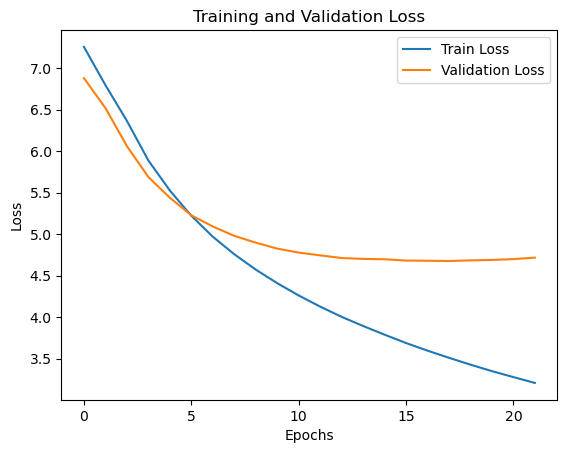

In [100]:
plt.plot(range(len(train_losses)), train_losses, label='Train Loss')
plt.plot(range(len(val_losses)), val_losses, label='Validation Loss')
plt.legend()
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.show()

### **Step 4. 실제 결과와 요약문 비교하기 (추상적 요약)**

- 원래의 요약문(haedline 열)과 학습을 통해 얻은 추상적 요약의 결과를 비교

In [101]:
src_index_to_word = {idx: word for word, idx in src_vocab.items()} # 원문 단어 집합에서 정수 -> 단어를 얻음
tar_word_to_index = tar_vocab # 요약 단어 집합에서 단어 -> 정수를 얻음
tar_index_to_word = {idx: word for word, idx in tar_vocab.items()} # 요약 단어 집합에서 정수 -> 단어를 얻음

print('=3')

=3


In [102]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
decoder.to(device)

# 인코더 설계
def encode_input(encoder, input_seq):
    encoder_outputs, hidden, cell = encoder(input_seq)
    return encoder_outputs, hidden, cell

# 이전 시점의 상태들을 저장하는 텐서
num_layers = 3  # 디코더 LSTM 레이어 개수 (설정에 맞춰 조정)
batch_size = 1

decoder_state_input_h = torch.zeros((num_layers, batch_size, hidden_size), dtype=torch.float, device=device)
decoder_state_input_c = torch.zeros((num_layers, batch_size, hidden_size), dtype=torch.float, device=device)
decoder_input = torch.zeros((batch_size, 1), dtype=torch.long, device=device)

dec_emb2 = decoder.embedding(decoder_input)

# 문장의 다음 단어를 예측하기 위해서 초기 상태(initial_state)를 이전 시점의 상태로 사용. 이는 뒤의 함수 decode_sequence()에 구현
# 훈련 과정에서와 달리 LSTM의 리턴하는 은닉 상태와 셀 상태인 state_h와 state_c를 버리지 않음.
decoder_outputs2, state_h2, state_c2 = decoder(decoder_input, decoder_state_input_h, decoder_state_input_c)

print('=3')

=3


In [103]:
class DecoderWithAttention(nn.Module):
    def __init__(self, decoder, attention, hidden_size, vocab_size):
        super(DecoderWithAttention, self).__init__()
        self.decoder = decoder  # 기존 디코더
        self.attention = attention  # 어텐션 레이어
        self.concat = nn.Linear(hidden_size * 2, hidden_size)  # 어텐션 결합 레이어
        self.output_layer = nn.Linear(hidden_size, vocab_size)  # 최종 출력층
        self.softmax = nn.Softmax(dim=-1)  # 소프트맥스

    def forward(self, decoder_inputs, decoder_hidden_state, decoder_state_h, decoder_state_c):
        # 디코더 실행
        decoder_outputs, state_h, state_c = self.decoder(decoder_inputs, decoder_state_h, decoder_state_c)

        # 어텐션 적용
        attn_out = self.attention(decoder_outputs, decoder_hidden_state)

        # 어텐션과 디코더 출력 결합
        decoder_concat_output = torch.cat((decoder_outputs, attn_out), dim=-1)
        decoder_concat_output = torch.tanh(self.concat(decoder_concat_output))

        # 최종 출력층 적용
        decoder_outputs2 = self.softmax(self.output_layer(decoder_concat_output))

        return decoder_outputs2, state_h, state_c

# 기존 Attention 클래스 사용
attention_layer = Attention_dot(hidden_size)

# 디코더 모델 생성
decoder_model = DecoderWithAttention(decoder, attention_layer, hidden_size, tar_vocab_size)
print('=3')

=3


In [104]:
def decode_sequence(input_seq, encoder, decoder, tar_word_to_index, tar_index_to_word, text_max_len, summary_max_len, device):
    # 입력을 PyTorch Tensor로 변환
    input_seq = torch.tensor(input_seq, dtype=torch.long, device=device)

    # 인코더 실행하여 초기 상태(hidden, cell) 얻기
    with torch.no_grad():
        e_out, e_h, e_c = encoder(input_seq)

    e_out = e_out.repeat(1, text_max_len, 1)  # 차원 조정 (np.tile 대신 repeat 사용)

    # <SOS>에 해당하는 토큰 생성
    target_seq = torch.zeros((1, 1), dtype=torch.long, device=device)
    target_seq[0, 0] = tar_word_to_index['sostoken']

    stop_condition = False
    decoded_sentence = ''

    while not stop_condition:
        # 디코더 실행
        with torch.no_grad():
            output_tokens, h, c = decoder(target_seq, e_h, e_c)

        # 가장 높은 확률을 가진 단어 선택
        sampled_token_index = torch.argmax(output_tokens[0, -1, :]).item()
        sampled_token = tar_index_to_word[sampled_token_index]

        if sampled_token != 'eostoken':
            decoded_sentence += ' ' + sampled_token

        # 종료 조건: <eos>에 도달하거나 최대 길이를 초과하면 중단
        if sampled_token == 'eostoken' or len(decoded_sentence.split()) >= (summary_max_len - 1):
            stop_condition = True

        # 길이가 1인 타겟 시퀀스를 업데이트
        target_seq = torch.zeros((1, 1), dtype=torch.long, device=device)
        target_seq[0, 0] = sampled_token_index

        # 상태 업데이트
        e_h, e_c = h, c

    return decoded_sentence
print("=3")

=3


In [105]:
# 원문의 정수 시퀀스를 텍스트 시퀀스로 변환
def seq2text(input_seq):
    temp = ''
    for i in input_seq:
        key = int(i.item())  # PyTorch Tensor → int 변환
        if key != 0:  # 패딩(0) 제외
            temp = temp + src_index_to_word.get(key, "<UNK>") + ' '  # 안전한 조회
    return temp.strip()

# 요약문의 정수 시퀀스를 텍스트 시퀀스로 변환
def seq2summary(input_seq):
    temp = ''
    for i in input_seq:
        key = int(i.item())  # PyTorch Tensor → int 변환
        if key != 0 and key != tar_word_to_index['sostoken'] and key != tar_word_to_index['eostoken']:
            temp = temp + tar_index_to_word.get(key, "<UNK>") + ' '  # 안전한 조회
    return temp.strip()  # 양쪽 공백 제거

print('=3')

=3


In [106]:
%%time
for i in range(50, 100):
    print("원문 :", seq2text(encoder_input_test[i]))
    print("실제 요약 :", seq2summary(decoder_input_test[i]))
    input_seq = torch.tensor(encoder_input_test[i], dtype=torch.long, device=device).unsqueeze(0)
    print("예측 요약 :", decode_sequence(input_seq, encoder, decoder, tar_word_to_index, tar_index_to_word, text_max_len, headline_max_len, device))
    print("\n")

원문 : taapsee pannu said star kids earned space actors star kids slogged worked scratch despite easily taken project hurts added taapsee said times think kahan aa gaye ya kyun aa gaye
실제 요약 : star kids haven t earned the space we <UNK> for taapsee
예측 요약 :  students at its gets the gets gets gets gets gets gets gets gets gets


원문 : fight broke amongst passengers florida airport monday following cancellation nine spirit airlines flights reportedly several arrests also made passengers began yell pound counters spirit airlines flights cancelled last week across united states pilots contracts
실제 요약 : passengers fight at us airport over nine cancelled flights
예측 요약 :  home at in shows slams without work will gets gets gets gets gets gets


원문 : actor amitabh bachchan sharing old pictures family mother teji bachchan birth anniversary sunday wrote blog post introduced theatre films music ballroom dancing added memories nothing material else
실제 요약 : big b shares old pics on his mother s birth a

<timed exec>:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
/tmp/ipykernel_136/366614501.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  input_seq = torch.tensor(input_seq, dtype=torch.long, device=device)


원문 : south korean researchers claimed identify gas hydrates combustible frozen mixture water natural gas form oceans team found negatively charged minerals clay rich oceanic sedimentary deposits promote formation gas hydrates soon able commercially produce methane gas natural gas hydrate deposits said researchers
실제 요약 : scientists uncover how <UNK> ice forms under the sea
예측 요약 :  students home 5 work the gets gets gets gets gets being being being ban


원문 : us based researchers using nasa climate projections warn warmer temperatures could cause six extra nights sleep loss per individuals per month increasing nights researchers found temperature increase translated three nights insufficient sleep sleep loss could increase disease susceptibility harm psychological well researchers said
실제 요약 : <UNK> temperatures could disrupt sleep patterns study
예측 요약 :  students after 5 kohli he me 15 kohli last kohli last kohli being cm


원문 : driver bus fell gorge telangana killing least conferred 

#### **결과** 
- 단어 단어를 계속해서 뱉어냄( gets, no 가 연속적으로 나온다)
- 주어를 못 찾는다

### **Step 5. Summa을 이용해서 추출적 요약해보기**

In [107]:
from summa.summarizer import summarize

In [108]:
data['text']

0        saurav kant alumnus upgrad iiit pg program mac...
1        kunal shah credit card bill payment platform c...
2        new zealand defeated india wickets fourth odi ...
3        aegon life iterm insurance plan customers enjo...
4        speaking sexual harassment allegations rajkuma...
                               ...                        
98396    crpf jawan tuesday axed death sharp edged weap...
98397    uff yeh first song sonakshi sinha starrer upco...
98398    according reports new version science fiction ...
98399    new music video shows rapper snoop dogg aiming...
98400    madhesi morcha alliance seven political partie...
Name: text, Length: 98040, dtype: object

In [109]:
from summa.summarizer import summarize

for i in range(5):
    text = data['text'].iloc[i]

    # 🔥 문장 끝에 . 추가
    if not text.endswith('.'):
        text = text + '.'

    # 🔥 요약 수행
    summary = summarize(text, ratio=0.3)

    # 🔥 요약 안 나오면 fallback
    if summary.strip() == "":
        summary = text[:100]

    print(f"\n[원문 {i}]")
    print(text)

    print("\n[요약]")
    print(summary)


[원문 0]
saurav kant alumnus upgrad iiit pg program machine learning artificial intelligence sr systems engineer infosys almost years work experience program upgrad degree career support helped transition data scientist tech mahindra salary hike upgrad online power learning powered lakh careers.

[요약]
saurav kant alumnus upgrad iiit pg program machine learning artificial intelligence sr systems engin

[원문 1]
kunal shah credit card bill payment platform cred gave users chance win free food swiggy one year pranav kaushik delhi techie bagged reward spending cred coins users get one cred coin per rupee bill paid used avail rewards brands like ixigo bookmyshow ubereats cult fit.

[요약]
kunal shah credit card bill payment platform cred gave users chance win free food swiggy one year pr

[원문 2]
new zealand defeated india wickets fourth odi hamilton thursday win first match five match odi series india lost international match rohit sharma captaincy consecutive victories dating back march match w

---------------------------------

### 문법 완성도

In [110]:
def grammar_score(sentence):
    words = sentence.split()
    
    if len(words) < 3:
        return 1  # 너무 짧으면 낮음
    
    unique_ratio = len(set(words)) / len(words)
    
    # 반복 많으면 점수 낮게
    if unique_ratio < 0.5:
        return 2
    
    # 너무 이상하면 낮음
    if "<UNK>" in sentence:
        return 2
    
    return 4  # 기본 점수

### 핵심 단어 포함

In [111]:
def keyword_score(source, summary):
    src_words = set(source.split())
    sum_words = set(summary.split())
    
    if len(sum_words) == 0:
        return 0
    
    overlap = src_words.intersection(sum_words)
    
    return round(len(overlap) / len(sum_words), 2)

In [112]:
import torch
import pandas as pd
import re
from summa.summarizer import summarize

# ================================
# 🔹 전처리 함수 (Summa용 복구)
# ================================
def clean_text(text):
    text = re.sub(r'\\w+', ' ', text)   # \w 제거
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

def make_sentences(text, n=10):
    words = text.split()
    sentences = [' '.join(words[i:i+n]) for i in range(0, len(words), n)]
    return '. '.join(sentences)

# ================================
# 🔹 평가 함수
# ================================
def grammar_score(sentence):
    words = sentence.split()
    
    if len(words) < 3:
        return 1
    
    unique_ratio = len(set(words)) / len(words)
    
    if unique_ratio < 0.5:
        return 2
    
    if "<UNK>" in sentence:
        return 2
    
    return 4

def keyword_score(source, summary):
    src_words = set(source.split())
    sum_words = set(summary.split())
    
    if len(sum_words) == 0:
        return 0
    
    overlap = src_words.intersection(sum_words)
    
    return round(len(overlap) / len(sum_words), 2)

# ================================
# 🔹 비교 실행
# ================================
results = []

for i in range(10):

    # 🔹 원문
    text = data['text'].iloc[i]
    real = data['headlines'].iloc[i]

    # ================================
    # 🔥 Seq2Seq
    # ================================
    src = torch.tensor(encoder_input_test[i], dtype=torch.long, device=device).unsqueeze(0)

    seq_pred = decode_sequence(
        src, encoder, decoder,
        tar_word_to_index, tar_index_to_word,
        text_max_len, headline_max_len, device
    )

    # ================================
    # 🔥 Summa
    # ================================
    clean = clean_text(text)
    fixed_text = make_sentences(clean)

    summa_pred = summarize(fixed_text, ratio=0.3)

    # 🔥 fallback
    if summa_pred.strip() == "":
        summa_pred = text[:100]

    # ================================
    # 🔥 평가
    # ================================
    seq_grammar = grammar_score(seq_pred)
    summa_grammar = grammar_score(summa_pred)

    seq_keyword = keyword_score(text, seq_pred)
    summa_keyword = keyword_score(text, summa_pred)

    # ================================
    # 🔹 저장
    # ================================
    results.append({
        "원문": text[:50],
        "실제 요약": real,
        "Seq2Seq 요약": seq_pred,
        "Summa 요약": summa_pred,
        "Seq2Seq 문법": seq_grammar,
        "Summa 문법": summa_grammar,
        "Seq2Seq 핵심단어": seq_keyword,
        "Summa 핵심단어": summa_keyword
    })

# ================================
# 🔹 DataFrame
# ================================
df = pd.DataFrame(results)
df

/tmp/ipykernel_136/2285601926.py:63: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  src = torch.tensor(encoder_input_test[i], dtype=torch.long, device=device).unsqueeze(0)
/tmp/ipykernel_136/366614501.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  input_seq = torch.tensor(input_seq, dtype=torch.long, device=device)


,원문,실제 요약,Seq2Seq 요약,Summa 요약,Seq2Seq 문법,Summa 문법,Seq2Seq 핵심단어,Summa 핵심단어
0,saurav kant alumnus upgrad iiit pg program mac...,upGrad learner switches to career in ML & Al w...,chief at to gets the gets gets gets gets gets...,saurav kant alumnus upgrad iiit pg program mac...,2,4,0.00,0.90
1,kunal shah credit card bill payment platform c...,Delhi techie wins free food from Swiggy for on...,students home 15 work work work asks asks wit...,techie bagged reward spending cred coins users...,4,4,0.00,0.90
2,new zealand defeated india wickets fourth odi ...,New Zealand end Rohit Sharma-led India's 12-ma...,run at court last asks calls without asks ask...,first match five match odi series india lost i...,4,4,0.00,0.89
3,aegon life iterm insurance plan customers enjo...,Aegon life iTerm insurance plan helps customer...,claims at without the gets the gets gets gets...,paid save taxes plan provides life cover age y...,2,4,0.00,0.90
4,speaking sexual harassment allegations rajkuma...,"Have known Hirani for yrs, what if MeToo claim...",run at court last asks without the gets gets ...,hirani many years true metoo movement get dera...,4,4,0.00,0.89
5,pakistani singer rahat fateh ali khan denied r...,Rahat Fateh Ali Khan denies getting notice for...,asks without gets the gets the car takes to h...,directorate allegedly smuggling foreign curren...,4,4,0.00,0.90
6,india recorded lowest odi total new zealand ge...,"India get all out for 92, their lowest ODI tot...",play trump me in claims the claims claims cla...,india recorded lowest odi total new zealand ge...,4,4,0.00,0.90
7,weeks ex cbi director alok verma told departme...,Govt directs Alok Verma to join work 1 day bef...,chief 100 cm me 15 work the gets gets gets ge...,tenure director thursday ministry directed imm...,4,4,0.18,0.90
8,andhra pradesh cm chandrababu naidu said met u...,Called PM Modi 'sir' 10 times to satisfy his e...,10 kohli t win in claims the gets gets gets g...,andhra pradesh cm chandrababu naidu said met u...,4,4,0.00,1.00
9,congress candidate shafia zubair ramgarh assem...,"Cong wins Ramgarh bypoll in Rajasthan, takes t...",home home slams without the gets the gets get...,congress candidate shafia zubair ramgarh assem...,4,4,0.00,0.90


## 회고

- Seq2Seq 구조를 통해서 뉴스를 요약해보는 과정을 수행했다
- 성능과 OOV를 보면서 1만~2만 사이로 조정하는게 좋다고 한다
- 솔직히 LMS 내용을 그대로 따라가는 것도 벅차다. 그래서 코드를 복붙하면서 flow 따라가는데 바빴다.
- attention은 Seq2Seq의 정보 압축 문제를 해결하기 위해 등장했다. 기존 s2s는 모든 문장을 하나의 벡터에 압축해야했는데, 이는 긴 문장에 약한 단점이 있다. attention은 이러한 문제를 해결하기 위해서 등장했으며 디코더가 입력 전체를 필요할 때마다 참고할 수 있게 만들었다. Encoder - Decoder 구조를 통해서 문장을 의미있게 압축한 후 다시 문장으로 되돌리는 과정을 알 수 있었다
- attention은 transformer를 배우기 위해 필요한 개념이다
-
- **Seq2SeqwithAttehtnion을 사용해서 요약한 결과**
- 주어를 제대로 파악하지 못한다
- gets, no 와 같이 단어들을 요약문에서 반복해서 뱉어낸다. 찾아보니 이는 seq2seq에서 흔한 문제인 repetition problem(반복 생성 문제)라고 한다. 이러한 이유가 생기는 이유는 1. 확률적으로 안전한 단어를 반복하는데 attention이 특정 encoder 위치에 계속 집중하면 같은 정보를 반복해서 가져온다고 한다. 또한 inference 과정은 이전 출력에 의존하기 때문에 한번 반복이 되면 계속 반복이 증폭 될 수 있다고 한다.
- 반복 생성 문제를 줄이기 위해서는 1. Beam Search + lenght penality, 2.Repetition pnalty 등등 패널피를 주면서 반복되는걸 방지하는 방법들이 존재한다고 한다
- 요약문에 UNK둘이 존재했다. 아마 OOV문제가 생긴 것같다. OOV 문제는 이전 챕터인 Subword(BPE, SentencePiece)를 통해서 해결하면 된다.
- attention 모델을 사용했지만 문장 전체를 파악하지 못한 것 같다
- vocab을 늘리거나 다양하게 실험을 수행해야할 것 같다
- Summa 모델을 통한 요약은 굉장히 잘 되었고, 문장을 뽑아서 보아도 거의 주어, 서술어, 내용등 알맞게 요약되었다. 문장 비교를 위해 가져온 핵심 단어 포함 점수와 문법 점수를 Seq2SeqwithAttention 모델과 비교해보았다. Summa 는 핵심단어도 잘 포함했고, 문법적으로도 좋은 점수를 가졌던 반면에 구현한모델은 문법적으로는 이상하지 않았더라도 핵심 단어를 뽑아내지 못했던 것 같다
- 그리고 사실 Seq2SeqwithAttention 모델 결과보면 문법적으로도 과연 옳은가 라는 생각도 하게 된다